# Optimizer Comparison: Adam vs PerNeuronScaledSGD

This notebook analyzes the results of the optimizer comparison sweep to determine:
1. Which optimizer leads to faster convergence?
2. What is the optimal learning rate for each optimizer?
3. Does the advantage hold across different group sizes (p) and hidden dimensions (h)?

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
import json
from pathlib import Path
from collections import defaultdict
import re

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [22]:
# ============================================================================
# CONFIGURATION - Update this path if analyzing a different sweep
# ============================================================================
SWEEP_DIR = Path("../../sweep_results/optimizer_comparison_sweep_20260216_135908")

# Verify the sweep directory exists
if not SWEEP_DIR.exists():
    raise FileNotFoundError(f"Sweep directory not found: {SWEEP_DIR}")
print(f"Analyzing sweep: {SWEEP_DIR.name}")

Analyzing sweep: optimizer_comparison_sweep_20260216_135908


In [23]:
def parse_experiment_name(exp_name):
    """Parse experiment name to extract parameters.
    
    Example: 'p10_h160_lr0.0001_optimizeradam' -> 
             {'p': 10, 'h': 160, 'lr': 0.0001, 'optimizer': 'adam'}
    """
    pattern = r'p(\d+)_h(\d+)_lr([\d.]+)_optimizer(\w+)'
    match = re.match(pattern, exp_name)
    if match:
        return {
            'p': int(match.group(1)),
            'h': int(match.group(2)),
            'lr': float(match.group(3)),
            'optimizer': match.group(4)
        }
    return None

def load_experiment_results(sweep_dir):
    """Load all completed experiment results from sweep directory."""
    results = []
    
    for exp_dir in sweep_dir.iterdir():
        if not exp_dir.is_dir() or exp_dir.name == 'configs':
            continue
            
        # Check for run_summary.yaml in seed_0
        summary_path = exp_dir / 'seed_0' / 'run_summary.yaml'
        if not summary_path.exists():
            continue
            
        # Parse experiment name
        params = parse_experiment_name(exp_dir.name)
        if params is None:
            continue
            
        # Load run summary
        with open(summary_path) as f:
            summary = yaml.safe_load(f)
        
        # Load loss history to get steps to convergence
        loss_history_path = exp_dir / 'seed_0' / 'train_loss_history.npy'
        samples_seen_path = exp_dir / 'seed_0' / 'samples_seen.npy'
        
        if loss_history_path.exists() and samples_seen_path.exists():
            loss_history = np.load(loss_history_path)
            samples_seen = np.load(samples_seen_path)
            steps_to_convergence = int(samples_seen[-1]) if len(samples_seen) > 0 else None
            initial_loss = loss_history[0] if len(loss_history) > 0 else None
        else:
            steps_to_convergence = None
            initial_loss = None
            loss_history = None
            samples_seen = None
        
        results.append({
            'exp_name': exp_dir.name,
            **params,
            'final_train_loss': summary.get('final_train_loss'),
            'final_val_loss': summary.get('final_val_loss'),
            'training_time': summary.get('training_time'),
            'steps_to_convergence': steps_to_convergence,
            'initial_loss': initial_loss,
            'loss_history': loss_history,
            'samples_seen': samples_seen,
            'status': summary.get('status')
        })
    
    return results

# Load all results
results = load_experiment_results(SWEEP_DIR)
print(f"Loaded {len(results)} completed experiments")

# Extract unique parameter values
p_values = sorted(set(r['p'] for r in results))
h_values = sorted(set(r['h'] for r in results))
lr_values = sorted(set(r['lr'] for r in results))
optimizers = sorted(set(r['optimizer'] for r in results))

print(f"p values: {p_values}")
print(f"h values: {h_values}")
print(f"lr values: {lr_values}")
print(f"optimizers: {optimizers}")

Loaded 90 completed experiments
p values: [10, 25, 50]
h values: [160, 320, 640]
lr values: [0.0001, 0.001, 0.01, 0.1, 1.0]
optimizers: ['adam', 'per_neuron']


## 1. Steps to Convergence: Adam vs PerNeuronScaledSGD by Learning Rate

For each (p, h) combination, compare convergence speed across learning rates.

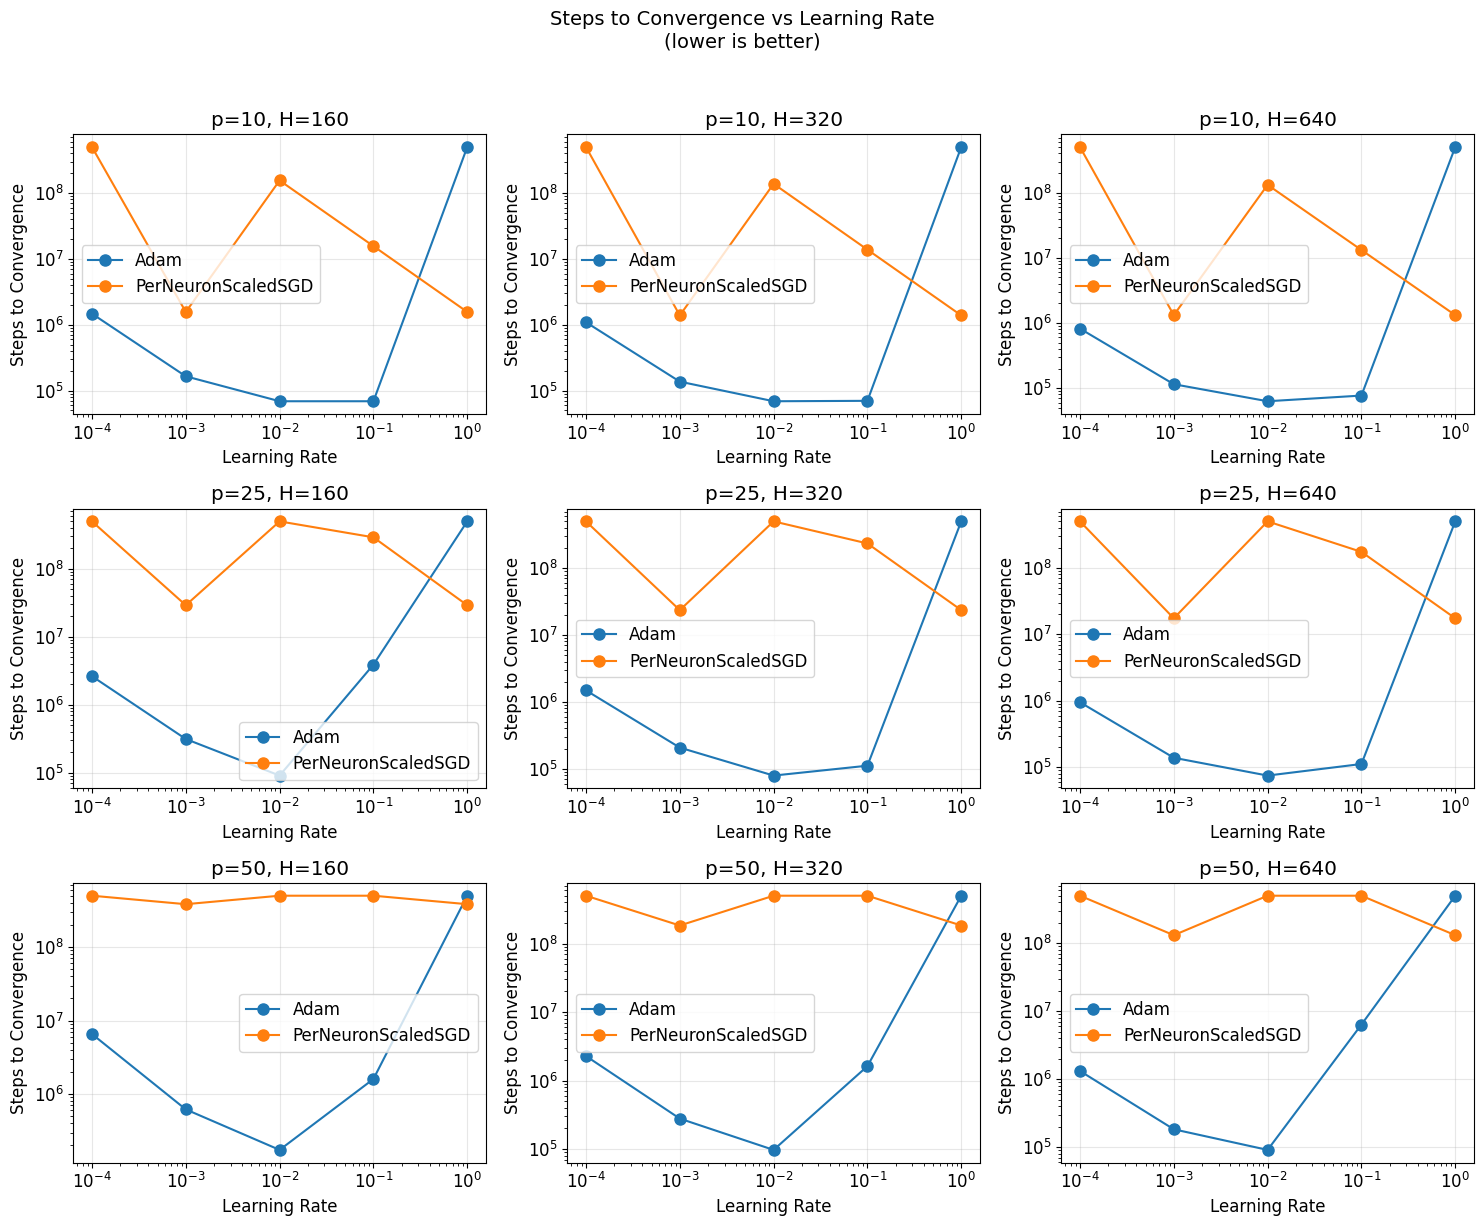

In [24]:
# Create lookup dictionary for easy access
results_lookup = {}
for r in results:
    key = (r['p'], r['h'], r['lr'], r['optimizer'])
    results_lookup[key] = r

# Plot: Steps to convergence vs learning rate, grouped by optimizer
fig, axes = plt.subplots(len(p_values), len(h_values), figsize=(5*len(h_values), 4*len(p_values)), squeeze=False)

for i, p in enumerate(p_values):
    for j, h in enumerate(h_values):
        ax = axes[i, j]
        
        for optimizer in optimizers:
            steps = []
            lrs = []
            for lr in lr_values:
                key = (p, h, lr, optimizer)
                if key in results_lookup and results_lookup[key]['steps_to_convergence'] is not None:
                    steps.append(results_lookup[key]['steps_to_convergence'])
                    lrs.append(lr)
            
            if steps:
                label = 'Adam' if optimizer == 'adam' else 'PerNeuronScaledSGD'
                color = 'tab:blue' if optimizer == 'adam' else 'tab:orange'
                ax.plot(lrs, steps, 'o-', label=label, color=color, markersize=8)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Steps to Convergence')
        ax.set_title(f'p={p}, H={h}')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Steps to Convergence vs Learning Rate\n(lower is better)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('optimizer_comparison_steps_vs_lr.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 2. Best Learning Rate for Each Optimizer

Find the optimal learning rate for each optimizer at each (p, h) setting.

In [25]:
# Find best LR for each optimizer at each (p, h)
best_results = {}

for p in p_values:
    for h in h_values:
        for optimizer in optimizers:
            best_steps = float('inf')
            best_lr = None
            best_result = None
            
            for lr in lr_values:
                key = (p, h, lr, optimizer)
                if key in results_lookup:
                    r = results_lookup[key]
                    if r['steps_to_convergence'] is not None and r['steps_to_convergence'] < best_steps:
                        best_steps = r['steps_to_convergence']
                        best_lr = lr
                        best_result = r
            
            if best_result is not None:
                best_results[(p, h, optimizer)] = {
                    'best_lr': best_lr,
                    'steps': best_steps,
                    'result': best_result
                }

# Display comparison table
print("Best Learning Rate and Steps to Convergence")
print("=" * 80)
print(f"{'p':>5} {'H':>5} | {'Adam LR':>10} {'Adam Steps':>12} | {'PN-SGD LR':>10} {'PN-SGD Steps':>12} | {'Winner':>10}")
print("-" * 80)

for p in p_values:
    for h in h_values:
        adam_key = (p, h, 'adam')
        pn_key = (p, h, 'per_neuron')
        
        adam_lr = best_results.get(adam_key, {}).get('best_lr', 'N/A')
        adam_steps = best_results.get(adam_key, {}).get('steps', float('inf'))
        pn_lr = best_results.get(pn_key, {}).get('best_lr', 'N/A')
        pn_steps = best_results.get(pn_key, {}).get('steps', float('inf'))
        
        if adam_steps < pn_steps:
            winner = 'Adam'
        elif pn_steps < adam_steps:
            winner = 'PN-SGD'
        else:
            winner = 'Tie'
        
        adam_lr_str = f"{adam_lr:.0e}" if isinstance(adam_lr, float) else adam_lr
        pn_lr_str = f"{pn_lr:.0e}" if isinstance(pn_lr, float) else pn_lr
        adam_steps_str = f"{adam_steps:,}" if adam_steps != float('inf') else 'N/A'
        pn_steps_str = f"{pn_steps:,}" if pn_steps != float('inf') else 'N/A'
        
        print(f"{p:>5} {h:>5} | {adam_lr_str:>10} {adam_steps_str:>12} | {pn_lr_str:>10} {pn_steps_str:>12} | {winner:>10}")

Best Learning Rate and Steps to Convergence
    p     H |    Adam LR   Adam Steps |  PN-SGD LR PN-SGD Steps |     Winner
--------------------------------------------------------------------------------
   10   160 |      1e-02       69,000 |      1e-03    1,567,000 |       Adam
   10   320 |      1e-02       69,000 |      1e-03    1,387,000 |       Adam
   10   640 |      1e-02       63,000 |      1e-03    1,319,000 |       Adam
   25   160 |      1e-02       91,000 |      1e-03   29,189,000 |       Adam
   25   320 |      1e-02       79,000 |      1e-03   23,538,000 |       Adam
   25   640 |      1e-02       75,000 |      1e-03   17,410,000 |       Adam
   50   160 |      1e-02      174,000 |      1e-03  383,355,000 |       Adam
   50   320 |      1e-02       97,000 |      1e-03  183,604,000 |       Adam
   50   640 |      1e-02       91,000 |      1e-03  131,207,000 |       Adam


## 3. Speedup Ratio: PerNeuronScaledSGD vs Adam

Visualize the speedup (or slowdown) of PerNeuronScaledSGD relative to Adam.

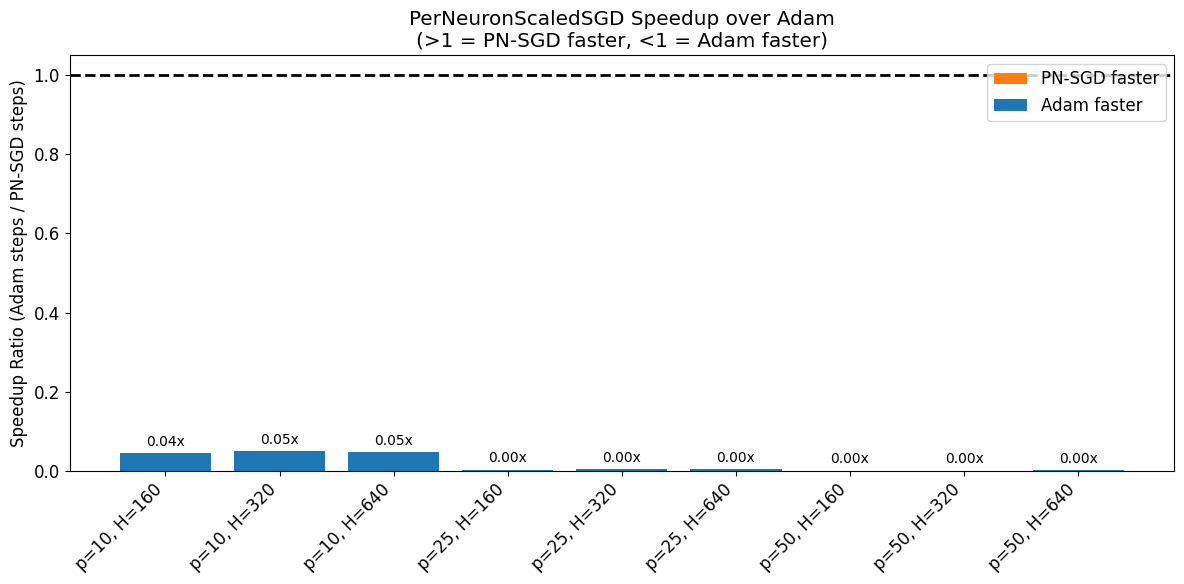

In [26]:
# Calculate speedup ratio: Adam_steps / PerNeuronScaledSGD_steps
# > 1 means PerNeuronScaledSGD is faster
# < 1 means Adam is faster

speedup_data = []

for p in p_values:
    for h in h_values:
        adam_key = (p, h, 'adam')
        pn_key = (p, h, 'per_neuron')
        
        if adam_key in best_results and pn_key in best_results:
            adam_steps = best_results[adam_key]['steps']
            pn_steps = best_results[pn_key]['steps']
            speedup = adam_steps / pn_steps
            speedup_data.append({
                'p': p,
                'h': h,
                'speedup': speedup,
                'adam_steps': adam_steps,
                'pn_steps': pn_steps
            })

if speedup_data:
    # Bar chart of speedup
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x_labels = [f"p={d['p']}, H={d['h']}" for d in speedup_data]
    speedups = [d['speedup'] for d in speedup_data]
    
    colors = ['tab:orange' if s > 1 else 'tab:blue' for s in speedups]
    bars = ax.bar(range(len(speedups)), speedups, color=colors)
    
    ax.axhline(y=1, color='black', linestyle='--', linewidth=2, label='Equal performance')
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel('Speedup Ratio (Adam steps / PN-SGD steps)')
    ax.set_title('PerNeuronScaledSGD Speedup over Adam\n(>1 = PN-SGD faster, <1 = Adam faster)')
    
    # Add value labels on bars
    for bar, speedup in zip(bars, speedups):
        height = bar.get_height()
        ax.annotate(f'{speedup:.2f}x',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='tab:orange', label='PN-SGD faster'),
        Patch(facecolor='tab:blue', label='Adam faster')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('optimizer_comparison_speedup.pdf', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("Not enough data to compute speedup ratios yet.")

## 4. Training Loss Curves (Best LR for Each Optimizer)

Compare training dynamics using the best learning rate for each optimizer.

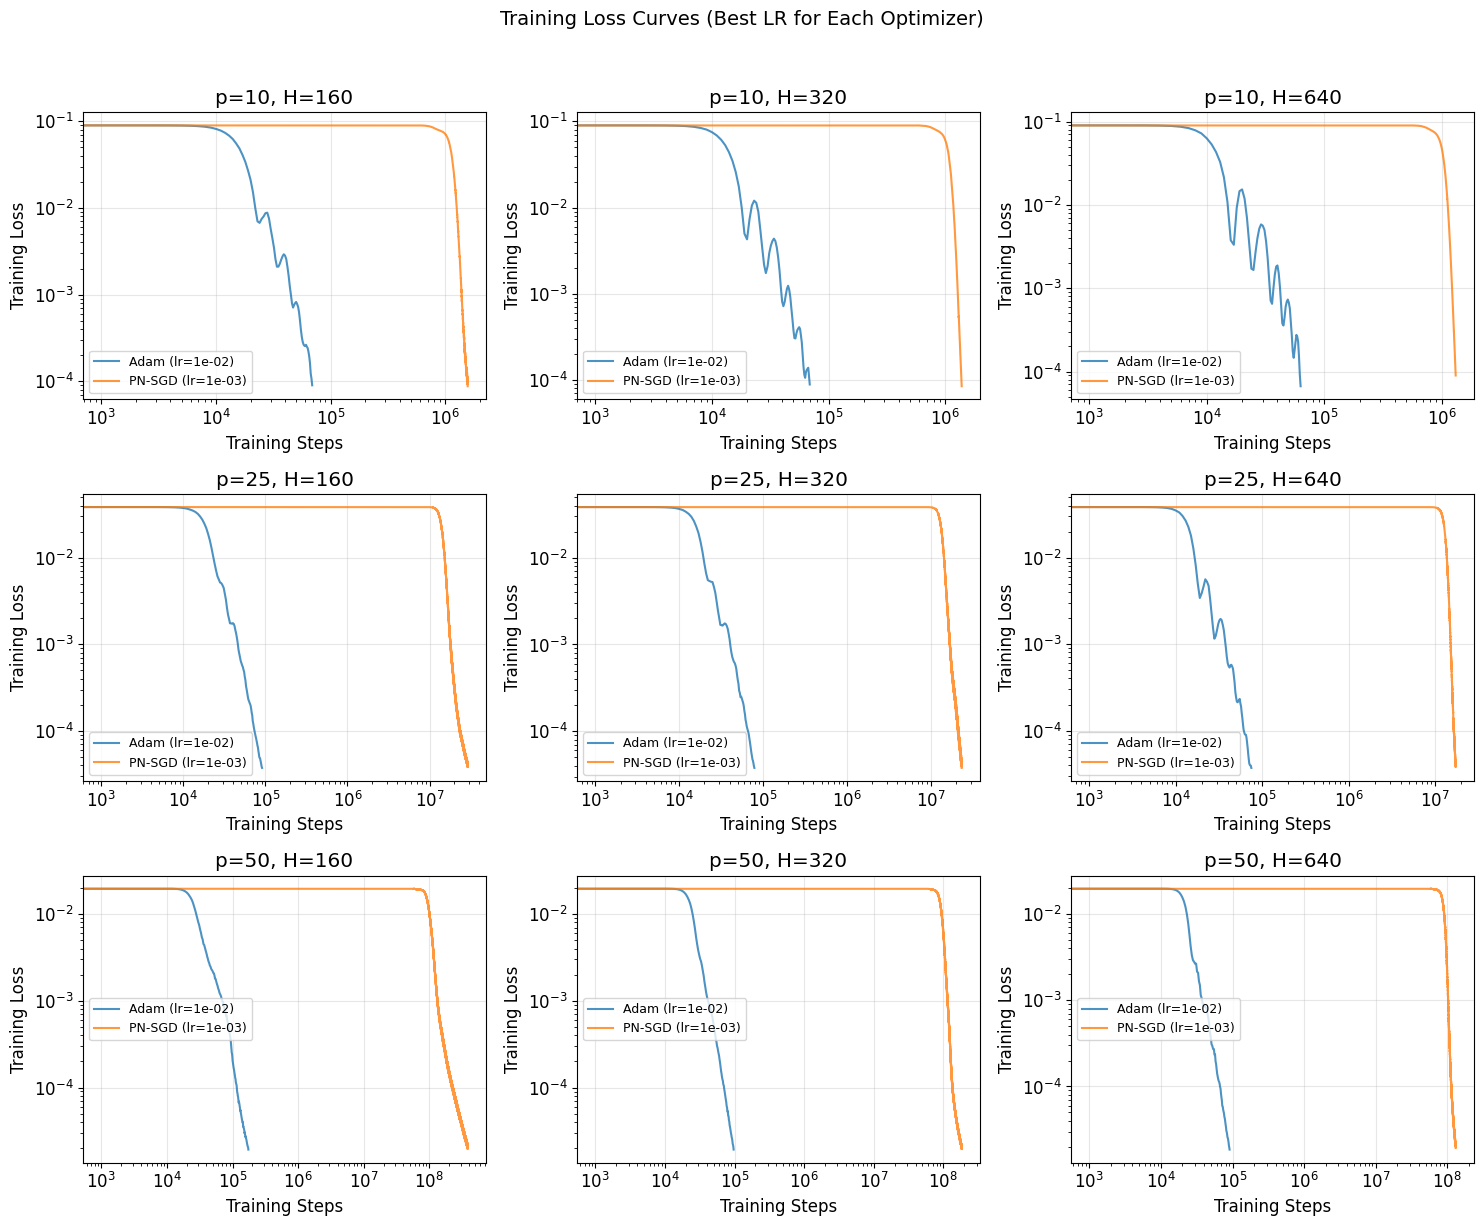

In [27]:
# Plot training loss curves for best LR at each (p, h)
fig, axes = plt.subplots(len(p_values), len(h_values), figsize=(5*len(h_values), 4*len(p_values)), squeeze=False)

for i, p in enumerate(p_values):
    for j, h in enumerate(h_values):
        ax = axes[i, j]
        
        for optimizer in optimizers:
            key = (p, h, optimizer)
            if key in best_results:
                r = best_results[key]['result']
                if r['loss_history'] is not None and r['samples_seen'] is not None:
                    label = f"Adam (lr={best_results[key]['best_lr']:.0e})" if optimizer == 'adam' else f"PN-SGD (lr={best_results[key]['best_lr']:.0e})"
                    color = 'tab:blue' if optimizer == 'adam' else 'tab:orange'
                    ax.plot(r['samples_seen'], r['loss_history'], label=label, color=color, alpha=0.8)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Training Steps')
        ax.set_ylabel('Training Loss')
        ax.set_title(f'p={p}, H={h}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle('Training Loss Curves (Best LR for Each Optimizer)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('optimizer_comparison_loss_curves.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 5. Learning Rate Sensitivity

How sensitive is each optimizer to learning rate choice?

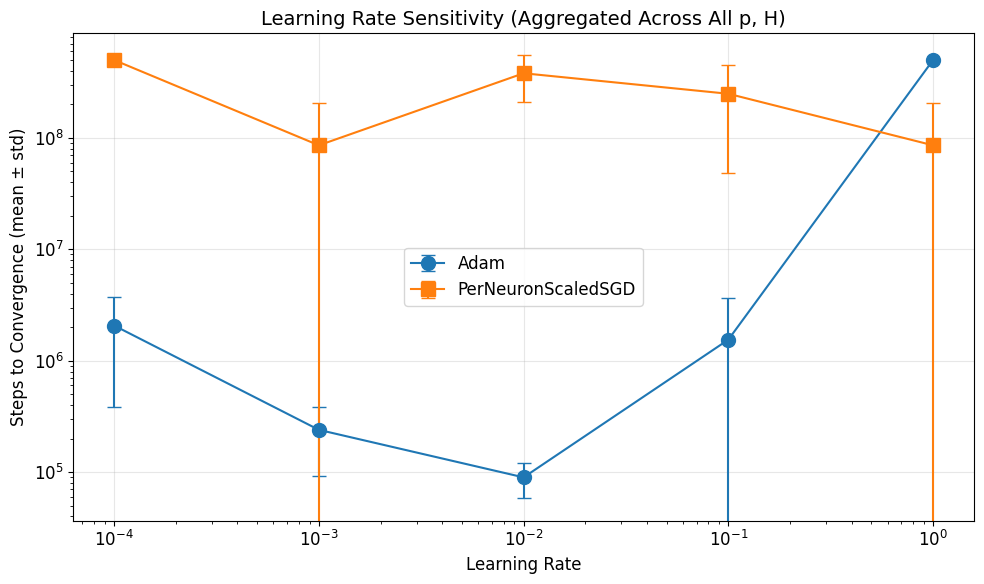

In [28]:
# Aggregate across all (p, h) to see overall LR sensitivity
adam_by_lr = defaultdict(list)
pn_by_lr = defaultdict(list)

for r in results:
    if r['steps_to_convergence'] is not None:
        if r['optimizer'] == 'adam':
            adam_by_lr[r['lr']].append(r['steps_to_convergence'])
        else:
            pn_by_lr[r['lr']].append(r['steps_to_convergence'])

fig, ax = plt.subplots(figsize=(10, 6))

# Adam
if adam_by_lr:
    lrs = sorted(adam_by_lr.keys())
    means = [np.mean(adam_by_lr[lr]) for lr in lrs]
    stds = [np.std(adam_by_lr[lr]) for lr in lrs]
    ax.errorbar(lrs, means, yerr=stds, fmt='o-', label='Adam', color='tab:blue', capsize=5, markersize=10)

# PerNeuronScaledSGD
if pn_by_lr:
    lrs = sorted(pn_by_lr.keys())
    means = [np.mean(pn_by_lr[lr]) for lr in lrs]
    stds = [np.std(pn_by_lr[lr]) for lr in lrs]
    ax.errorbar(lrs, means, yerr=stds, fmt='s-', label='PerNeuronScaledSGD', color='tab:orange', capsize=5, markersize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Learning Rate', fontsize=12)
ax.set_ylabel('Steps to Convergence (mean ± std)', fontsize=12)
ax.set_title('Learning Rate Sensitivity (Aggregated Across All p, H)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison_lr_sensitivity.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 6. Summary Statistics

In [29]:
# Overall summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Count wins
adam_wins = 0
pn_wins = 0
ties = 0

for p in p_values:
    for h in h_values:
        adam_key = (p, h, 'adam')
        pn_key = (p, h, 'per_neuron')
        
        if adam_key in best_results and pn_key in best_results:
            adam_steps = best_results[adam_key]['steps']
            pn_steps = best_results[pn_key]['steps']
            
            if adam_steps < pn_steps:
                adam_wins += 1
            elif pn_steps < adam_steps:
                pn_wins += 1
            else:
                ties += 1

total = adam_wins + pn_wins + ties
if total > 0:
    print(f"\nWin/Loss Record (at optimal LR for each):")
    print(f"  Adam wins:            {adam_wins}/{total} ({100*adam_wins/total:.1f}%)")
    print(f"  PerNeuronScaledSGD wins: {pn_wins}/{total} ({100*pn_wins/total:.1f}%)")
    print(f"  Ties:                 {ties}/{total} ({100*ties/total:.1f}%)")

# Best overall LR for each optimizer
if adam_by_lr:
    best_adam_lr = min(adam_by_lr.keys(), key=lambda lr: np.mean(adam_by_lr[lr]))
    print(f"\nBest LR for Adam (avg across p,H): {best_adam_lr:.0e} (mean steps: {np.mean(adam_by_lr[best_adam_lr]):,.0f})")

if pn_by_lr:
    best_pn_lr = min(pn_by_lr.keys(), key=lambda lr: np.mean(pn_by_lr[lr]))
    print(f"Best LR for PerNeuronScaledSGD (avg across p,H): {best_pn_lr:.0e} (mean steps: {np.mean(pn_by_lr[best_pn_lr]):,.0f})")

# Average speedup
if speedup_data:
    avg_speedup = np.mean([d['speedup'] for d in speedup_data])
    print(f"\nAverage speedup (Adam/PN-SGD): {avg_speedup:.2f}x")
    if avg_speedup > 1:
        print(f"  → PerNeuronScaledSGD is {avg_speedup:.2f}x faster on average")
    else:
        print(f"  → Adam is {1/avg_speedup:.2f}x faster on average")


SUMMARY

Win/Loss Record (at optimal LR for each):
  Adam wins:            9/9 (100.0%)
  PerNeuronScaledSGD wins: 0/9 (0.0%)
  Ties:                 0/9 (0.0%)

Best LR for Adam (avg across p,H): 1e-02 (mean steps: 89,778)
Best LR for PerNeuronScaledSGD (avg across p,H): 1e+00 (mean steps: 85,841,778)

Average speedup (Adam/PN-SGD): 0.02x
  → Adam is 58.44x faster on average


## 7. Recommendation

In [ ]:
print("\n" + "="*80)
print("RECOMMENDATION FOR FUTURE SWEEPS")
print("="*80)

if pn_wins > adam_wins:
    print(f"\n✓ Use PerNeuronScaledSGD with lr={best_pn_lr:.0e}")
    print(f"  - Won {pn_wins}/{total} comparisons at optimal LR")
    if speedup_data:
        print(f"  - Average speedup: {avg_speedup:.2f}x faster than Adam")
elif adam_wins > pn_wins:
    print(f"\n✓ Use Adam with lr={best_adam_lr:.0e}")
    print(f"  - Won {adam_wins}/{total} comparisons at optimal LR")
    if speedup_data:
        print(f"  - Average speedup: {1/avg_speedup:.2f}x faster than PerNeuronScaledSGD")
else:
    print("\n⚠ Results are inconclusive - optimizers performed similarly.")
    print("  Consider running more experiments or checking specific (p, H) regimes.")


RECOMMENDATION FOR FUTURE SWEEPS

✓ Use Adam with lr=1e-02
  - Won 9/9 comparisons at optimal LR
  - Average speedup: 58.44x faster than PerNeuronScaledSGD


: 